In [1]:
import json
import pathlib

import matplotlib.pyplot as plt
import numpy as np

from common import (
    INDEX_ORDER,
    index_colors,
    index_markers,
    transform_duckdb_index_name,
    transform_pgvector_index_name,
    apply_style,
    PLOT_DPI,
    LABEL_FONTSIZE,
    TICK_FONTSIZE,
    TITLE_FONTSIZE,
    MARKER_SIZE,
    FONT_COLOR,
    TICK_FONTS_COLOR,
)


def compute_qps(metrics: dict) -> float:
    """Compute QPS from serial_latencies (seconds)."""
    latencies = metrics.get("serial_latencies")
    if not latencies:
        raise ValueError("serial_latencies is missing or empty in metrics")
    return 1.0 / np.mean(latencies)


FILTER_TYPE_TITLES = {
    "EM": "Exact Match (EM)",
    "R": "Range (R)",
    "EMIS": "Exact Match In Set (EMIS)",
}

FILTER_TYPE_ORDER = ["EM", "R", "EMIS"]

# ---------------------------------------------------------------------------
# 1. Load all result JSONs from the index_filtered_search results directory
# ---------------------------------------------------------------------------
records = []

# Load DuckDB results
duckdb_results_dir = pathlib.Path("../experiments/results/index_filtered_search/DuckDB")
duckdb_json_files = sorted(duckdb_results_dir.glob("*.json"))

for path in duckdb_json_files:
    with open(path) as f:
        data = json.load(f)
    for entry in data.get("results", []):
        metrics = entry["metrics"]
        task_cfg = entry["task_config"]
        db_cfg = task_cfg["db_config"]
        db_case_cfg = task_cfg["db_case_config"]
        case_cfg = task_cfg["case_config"]

        custom = case_cfg.get("custom_case", {})
        filter_type = custom.get("arxiv_filter_type")
        if filter_type is None:
            continue

        db_label = json.loads(db_cfg.get("db_label", "{}"))
        global_version = db_label.get("global_version", None)

        index_name = transform_duckdb_index_name(db_case_cfg, global_version)

        records.append({
            "recall": metrics["recall"],
            "serial_qps": compute_qps(metrics),
            "index": index_name,
            "filter_type": filter_type,
            "db_type": "DuckDB",
        })

# Load pgvector results (if available)
pgvector_results_dir = pathlib.Path("../experiments/results/index_filtered_search/pgvector")
pgvector_json_files = sorted(pgvector_results_dir.glob("*.json")) if pgvector_results_dir.exists() else []

for path in pgvector_json_files:
    with open(path) as f:
        data = json.load(f)
    for entry in data.get("results", []):
        metrics = entry["metrics"]
        task_cfg = entry["task_config"]
        db_case_cfg = task_cfg["db_case_config"]
        case_cfg = task_cfg["case_config"]

        custom = case_cfg.get("custom_case", {})
        filter_type = custom.get("arxiv_filter_type")
        if filter_type is None:
            continue

        index_name = transform_pgvector_index_name(db_case_cfg)

        records.append({
            "recall": metrics["recall"],
            "serial_qps": compute_qps(metrics),
            "index": index_name,
            "filter_type": filter_type,
            "db_type": "pgvector",
        })

print(f"Loaded {len(records)} results from {len(duckdb_json_files)} DuckDB files and {len(pgvector_json_files)} pgvector files")
records[:3]

Loaded 75 results from 75 DuckDB files and 0 pgvector files


[{'recall': 1.0,
  'serial_qps': np.float64(8.374780902595745),
  'index': 'DuckDB',
  'filter_type': 'EM',
  'db_type': 'DuckDB'},
 {'recall': 1.0,
  'serial_qps': np.float64(4.8968706293517705),
  'index': 'DuckDB',
  'filter_type': 'R',
  'db_type': 'DuckDB'},
 {'recall': 1.0,
  'serial_qps': np.float64(12.821811536707527),
  'index': 'DuckDB',
  'filter_type': 'EMIS',
  'db_type': 'DuckDB'}]

In [2]:
# ---------------------------------------------------------------------------
# 2. Determine filter types present in data
# ---------------------------------------------------------------------------
filter_types = [ft for ft in FILTER_TYPE_ORDER if any(r["filter_type"] == ft for r in records)]
print(f"Filter types: {filter_types}")

Filter types: ['EM', 'R', 'EMIS']


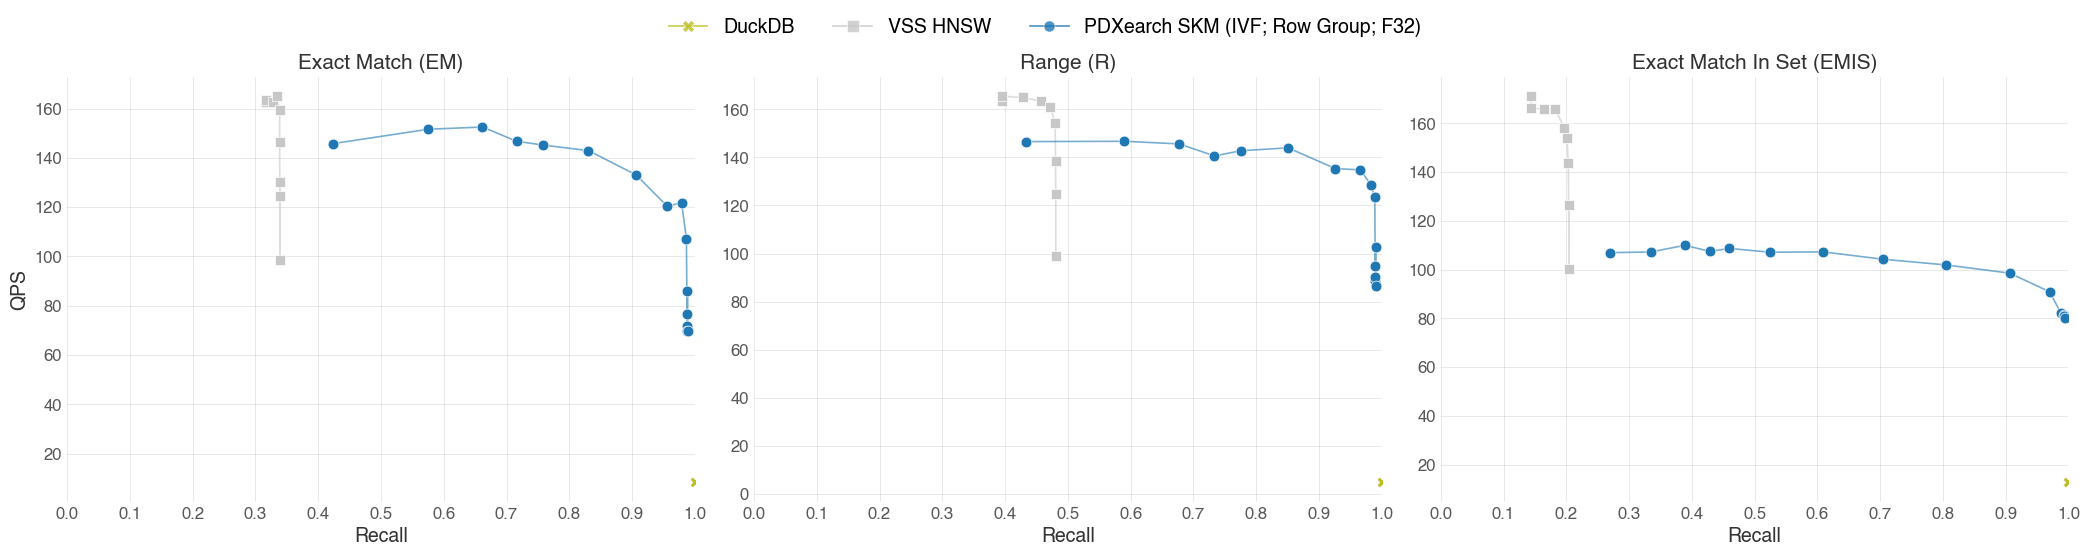

In [ ]:
# ---------------------------------------------------------------------------
# 3. Scatter plot: Recall vs QPS, one subplot per filter type
# ---------------------------------------------------------------------------
from collections import defaultdict
from matplotlib.lines import Line2D

apply_style()

# Group records: filter_type → index_type → list of (recall, qps) tuples
grouped: dict[str, dict[str, list[tuple[float, float]]]] = defaultdict(lambda: defaultdict(list))

for r in records:
    grouped[r["filter_type"]][r["index"]].append((r["recall"], r["serial_qps"]))

# Get all unique index types present in the data, in canonical order
all_index_types = set()
for ft in filter_types:
    all_index_types.update(grouped[ft].keys())
all_index_types = [idx for idx in INDEX_ORDER if idx in all_index_types]

# Create subplots: one per filter type (1 row, 3 cols)
n_plots = len(filter_types)
fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 5.5), squeeze=False)

for ft_idx, ft in enumerate(filter_types):
    ax = axes[0][ft_idx]

    for index_type in all_index_types:
        points = grouped[ft].get(index_type, [])
        if not points:
            continue

        points.sort(key=lambda p: p[0])
        recalls = [p[0] for p in points]
        qps_vals = [p[1] for p in points]

        color = index_colors.get(index_type, "#808080")
        marker = index_markers.get(index_type, "o")

        ax.scatter(recalls, qps_vals, label=index_type, color=color,
                   marker=marker, s=MARKER_SIZE, zorder=3, edgecolors='white', linewidths=0.5)
        ax.plot(recalls, qps_vals, color=color, linewidth=1.2, alpha=0.6, zorder=2)

    title = FILTER_TYPE_TITLES.get(ft, ft)
    ax.set_title(title, fontsize=TITLE_FONTSIZE, color=FONT_COLOR)
    ax.set_xlabel("Recall", fontsize=LABEL_FONTSIZE, color=FONT_COLOR)
    if ft_idx == 0:
        ax.set_ylabel("QPS", fontsize=LABEL_FONTSIZE, color=FONT_COLOR)

    ax.grid(True, linestyle='-', linewidth=0.6, color='gray', alpha=0.2)
    ax.set_axisbelow(True)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    ax.set_xlim(0, 1)
    ax.set_xticks([i / 10 for i in range(11)])

    ax.tick_params(axis='both', colors=TICK_FONTS_COLOR, length=0)
    ax.tick_params(axis='x', labelsize=TICK_FONTSIZE)
    ax.tick_params(axis='y', labelsize=TICK_FONTSIZE)

# Shared legend across all subplots
legend_handles = []
for index_type in all_index_types:
    color = index_colors.get(index_type, "#808080")
    marker = index_markers.get(index_type, "o")
    legend_handles.append(Line2D([0], [0], color=color, marker=marker, linestyle='-',
                                  markersize=8, markeredgecolor='white', markeredgewidth=0.5,
                                  linewidth=1.2, alpha=0.8, label=index_type))

fig.legend(handles=legend_handles, loc="upper center", ncol=len(all_index_types),
           frameon=False, fontsize=LABEL_FONTSIZE, bbox_to_anchor=(0.5, 1.02))

fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("index_filtered_search_arxiv.pdf", dpi=PLOT_DPI, bbox_inches='tight')